## 1. Imports

In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from keras.backend import clear_session
import gc

## 2. Data Loading (Strict Train/Test Separation)

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# Load labels
train_labels = pd.read_csv('/kaggle/input/raf-db-dataset/train_labels.csv')
test_labels = pd.read_csv('/kaggle/input/raf-db-dataset/test_labels.csv')

classes = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
label_map = {label: (idx+1) for idx, label in enumerate(classes)}

# Hàm worker để xử lý từng ảnh độc lập
def _process_single_image(img_path, idx):
    img = cv2.imread(img_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img_rgb, idx
    return None, None

# Load images function using Multi-threading
def load_data_multithread(dataset_dir, label_map, max_workers=None):
    if max_workers is None:
        max_workers = min(32, os.cpu_count() + 4) # Tối ưu hóa số lượng thread theo CPU
        
    image_paths_with_labels = []
    
    # 1. Quét toàn bộ thư mục để lấy đường dẫn
    for label, idx in label_map.items():
        folder_path = os.path.join(dataset_dir, str(idx))
        if not os.path.exists(folder_path):
            continue
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            image_paths_with_labels.append((img_path, idx))
            
    images, labels = [], []
    
    # 2. Bắn các task vào ThreadPool
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit tasks
        future_to_path = {
            executor.submit(_process_single_image, path, idx): (path, idx) 
            for path, idx in image_paths_with_labels
        }
        
        # Thu thập kết quả kết hợp tqdm
        for future in tqdm(as_completed(future_to_path), total=len(future_to_path), desc=f"Loading {os.path.basename(dataset_dir)}"):
            img, idx = future.result()
            if img is not None:
                images.append(img)
                labels.append(idx)
                
    return np.array(images), np.array(labels)

# Load datasets distinctly
print("Loading Train Data (Multi-threaded)...")
train_images_raw, train_labels_raw = load_data_multithread('/kaggle/input/raf-db-dataset/DATASET/train', label_map)

print("\nLoading Test Data (Multi-threaded)...")
X_test_raw, Y_test_raw = load_data_multithread('/kaggle/input/raf-db-dataset/DATASET/test', label_map)

Loading Train Data (Multi-threaded)...


Loading train:   0%|          | 0/12271 [00:00<?, ?it/s]


Loading Test Data (Multi-threaded)...


Loading test:   0%|          | 0/3068 [00:00<?, ?it/s]

## 3. Data Balancing (Applied ONLY to Train Data)

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import shuffle

# Undersample majority class ('happy' = 4)
def reduce_class(X, y, target_class, target_size):
    class_indices = np.where(y == target_class)[0]
    non_class_indices = np.where(y != target_class)[0]
    # Select exactly target_size instances
    reduced_class_indices = np.random.choice(class_indices, target_size, replace=False)
    final_indices = np.concatenate([reduced_class_indices, non_class_indices])
    return X[final_indices], y[final_indices]

X_reduced, y_reduced = reduce_class(train_images_raw, train_labels_raw, target_class=4, target_size=3500)

# Augment minority classes (Optimized for Memory & Speed)
def augment_classes_optimized(images, labels, target_counts):
    datagen = ImageDataGenerator(
        rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,  
        zoom_range=0.1, horizontal_flip=True, channel_shift_range=50.0, fill_mode='nearest'
    )
    
    # Khởi tạo list chứa các mảng numpy để nối 1 lần duy nhất ở cuối
    augmented_images_list = [images]
    augmented_labels_list = [labels]

    for target_class, target_count in target_counts.items():
        class_images = images[labels == target_class]
        current_count = len(class_images)
        augment_count = target_count - current_count
        
        if augment_count > 0:
            print(f'Class {target_class}: Generating {augment_count} augmented samples...')
            
            # Tối ưu Generator: Tăng batch_size để tận dụng vector hóa
            batch_size = min(128, current_count) 
            generator = datagen.flow(class_images, batch_size=batch_size, seed=42)
            
            generated_count = 0
            class_augmented_imgs = []
            
            while generated_count < augment_count:
                batch_imgs = next(generator)
                
                # Tính toán số lượng ảnh cần lấy từ batch hiện tại để không bị lố target
                take_count = min(len(batch_imgs), augment_count - generated_count)
                class_augmented_imgs.append(batch_imgs[:take_count].astype(np.uint8))
                generated_count += take_count
                
            # Gộp ảnh ảo của class hiện tại và đưa vào list tổng
            augmented_images_list.append(np.concatenate(class_augmented_imgs, axis=0))
            augmented_labels_list.append(np.full(augment_count, target_class))
            
    # Concatenate toàn bộ 1 lần duy nhất trên RAM
    print("Đang tổng hợp dữ liệu vào bộ nhớ (Concatenation)...")
    final_images = np.concatenate(augmented_images_list, axis=0)
    final_labels = np.concatenate(augmented_labels_list, axis=0)
    
    return final_images, final_labels

target_counts = {1: 3500, 2: 3500, 3: 3500, 5: 3500, 6: 3500, 7: 3500}
X_train_balanced, Y_train_balanced = augment_classes_optimized(X_reduced, y_reduced, target_counts)

# Shuffle the balanced train set to prevent learning ordering patterns
X_train_balanced, Y_train_balanced = shuffle(X_train_balanced, Y_train_balanced, random_state=42)

Class 1: Generating 2210 augmented samples...
Class 2: Generating 3219 augmented samples...
Class 3: Generating 2783 augmented samples...
Class 5: Generating 1518 augmented samples...
Class 6: Generating 2795 augmented samples...
Class 7: Generating 976 augmented samples...
Đang tổng hợp dữ liệu vào bộ nhớ (Concatenation)...


## 4. Preprocessing for CNN (Normalize, Reshape, Encoding)

In [4]:
# Normalize [0, 1]
X_train_norm = X_train_balanced / 255.0
X_test_norm = X_test_raw / 255.0

# Reshape for CNN explicitly (height, width, channels)
X_train_cnn = X_train_norm.reshape((X_train_norm.shape[0], 100, 100, 3))
X_test_cnn = X_test_norm.reshape((X_test_norm.shape[0], 100, 100, 3))

# One-hot encoding labels (subtract 1 because RAF-DB labels are 1-7)
Y_train_cat = to_categorical(Y_train_balanced - 1, num_classes=len(classes))
Y_test_cat = to_categorical(Y_test_raw - 1, num_classes=len(classes))

# Train Data Generator (only applied during fit process on Train Data)
datagen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,  
    horizontal_flip=True, fill_mode='nearest'
)
train_generator = datagen.flow(X_train_cnn, Y_train_cat, batch_size=32)

## 5. CNN Model Architecture & Training

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, Activation, add, Dense, Dropout, Multiply, Reshape, SpatialDropout2D
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Tối ưu lại L2 Regularization
regularization = l2(1e-4)

# --- Squeeze and Excitation Block (Attention) ---
def se_block(tensor, ratio=8):
    """
    Squeeze-and-Excitation block: Giúp model focus vào các feature map quan trọng.
    """
    filters = tensor.shape[-1]
    se = GlobalAveragePooling2D()(tensor)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', use_bias=False)(se)
    x = Multiply()([tensor, se])
    return x

inputs = Input(shape=(100, 100, 3))

# --- Base / Stem ---
x = Conv2D(16, (3, 3), strides=(1, 1), padding='same', kernel_regularizer=regularization, use_bias=False)(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(16, (3, 3), strides=(1, 1), padding='same', kernel_regularizer=regularization, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# --- Các Module được tăng cường Filter (32 -> 64 -> 128 -> 256) ---
filter_blocks = [32, 64, 128, 256]

for filters in filter_blocks:
    # Nhánh Skip Connection
    residual = Conv2D(filters, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
    residual = BatchNormalization()(residual)

    # Nhánh Separable Convolution
    x = SeparableConv2D(filters, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SeparableConv2D(filters, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    
    # Đưa qua SE Block
    x = se_block(x)
    
    # [TỐI ƯU MỚI] Áp dụng SpatialDropout2D với rate tăng dần theo độ sâu của mạng (tùy chọn 0.1 - 0.2)
    x = SpatialDropout2D(0.15)(x)

    x = add([x, residual])

# --- Classifier Head Nâng cấp ---
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=regularization)(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x) 

# Số lượng class (Chờ thông tin từ bạn)
num_classes = len(classes) 
outputs = Dense(num_classes, activation='softmax')(x)

# Khởi tạo model
cnn_model = Model(inputs=inputs, outputs=outputs, name="Advanced_FER_Model")

# [TỐI ƯU MỚI] Giảm learning rate và thêm label smoothing
optimizer = Adam(learning_rate=0.0005)
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

cnn_model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
cnn_model.summary()

# Training Callbacks
# Patience của ReduceLR nên nhỏ hơn EarlyStopping để nó có cơ hội giảm LR trước khi bị ngắt.
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=6, min_delta=0.0001, verbose=1, min_lr=1e-6) 
early_stop = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True, verbose=1)  
checkpoint = ModelCheckpoint(filepath='best_CNNModel.keras', monitor='val_accuracy', save_best_only=True, verbose=1) 

# Train Model
# LƯU Ý: Nếu train_generator là một object của ImageDataGenerator.flow() hoặc tf.data.Dataset, 
# tham số batch_size ở đây có thể gây thừa hoặc báo lỗi tùy phiên bản TF. 
CNN_History = cnn_model.fit(
    train_generator,
    epochs=120, 
    validation_data=(X_test_cnn, Y_test_cat), 
    callbacks=[reduce_lr, early_stop, checkpoint]
)

Model: "Advanced_FER_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 100, 100, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 100, 100, 16)   │            432 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 100, 100, 16)   │             64 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 100, 100, 16)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 100, 100, 16)   │          2,304 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 100, 100, 16)   │             64 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 100, 100, 16)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d          │ (None, 100, 100, 32)   │            656 │ activation_1[0][0]     │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 100, 100, 32)   │            128 │ separable_conv2d[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 100, 100, 32)   │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_1        │ (None, 100, 100, 32)   │          1,312 │ activation_2[0][0]     │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 100, 100, 32)   │            128 │ separable_conv2d_1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 50, 50, 32)     │              0 │ batch_normalization_4… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 32)             │              0 │ max_pooling2d[0][0]    │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 32)       │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)        

 Total params: 279,559 (1.07 MB)

 Trainable params: 276,103 (1.05 MB)

 Non-trainable params: 3,456 (13.50 KB)

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


765/766 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1897 - loss: 2.5095
Epoch 1: val_accuracy improved from -inf to 0.29433, saving model to best_CNNModel.keras
766/766 ━━━━━━━━━━━━━━━━━━━━ 106s 102ms/step - accuracy: 0.1897 - loss: 2.5091 - val_accuracy: 0.2943 - val_loss: 2.0633 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 1.


## 6. Evaluation & Plotting

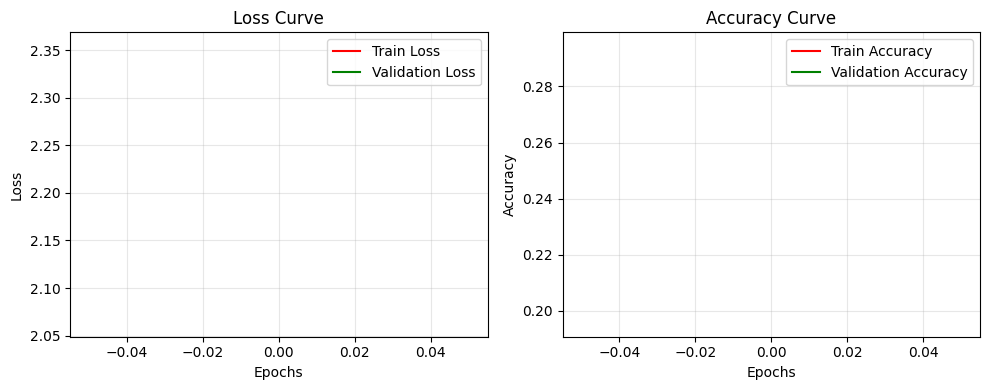

Train Loss: 2.0236 | Train Accuracy: 25.63%
Test Loss: 2.0633  | Test Accuracy: 29.43%


In [6]:
# Loss & Accuracy Curves
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(CNN_History.history['loss'], label='Train Loss', color='red')
ax[0].plot(CNN_History.history['val_loss'], label='Validation Loss', color='green')
ax[0].set_title('Loss Curve')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(CNN_History.history['accuracy'], label='Train Accuracy', color='red')
ax[1].plot(CNN_History.history['val_accuracy'], label='Validation Accuracy', color='green')
ax[1].set_title('Accuracy Curve')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation Results
train_result = cnn_model.evaluate(X_train_cnn, Y_train_cat, verbose=0)
test_result = cnn_model.evaluate(X_test_cnn, Y_test_cat, verbose=0)

print(f"Train Loss: {train_result[0]:.4f} | Train Accuracy: {train_result[1]*100:.2f}%")
print(f"Test Loss: {test_result[0]:.4f}  | Test Accuracy: {test_result[1]*100:.2f}%")

## 7. Classification Report & Confusion Matrix

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step

Classification Report:
              precision    recall  f1-score   support

    surprise       0.17      0.08      0.11       329
        fear       0.11      0.47      0.17        74
     disgust       0.07      0.20      0.11       160
       happy       0.51      0.55      0.53      1185
         sad       0.22      0.14      0.17       478
       angry       0.14      0.38      0.20       162
     neutral       0.29      0.05      0.08       680

    accuracy                           0.29      3068
   macro avg       0.21      0.27      0.20      3068
weighted avg       0.33      0.29      0.28      3068



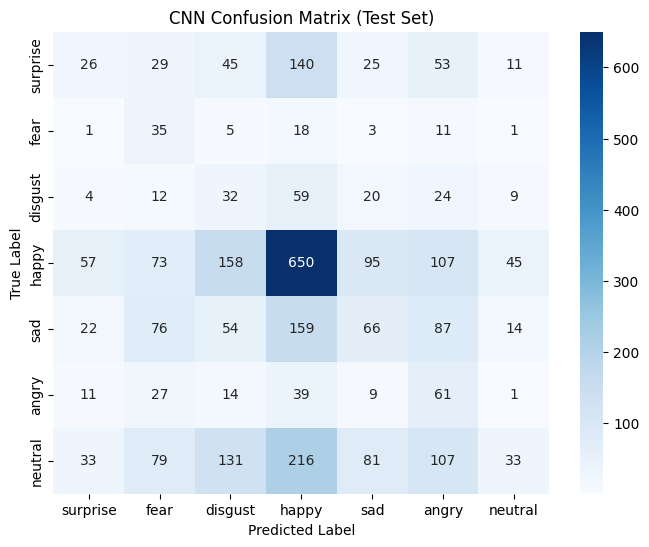

In [7]:
# Predictions on untouched Test Set
y_pred_prob = cnn_model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(Y_test_cat, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("CNN Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 8. Save Best Model & Clear Memory

In [8]:
final_model_path = 'best_cnn_model.h5'
cnn_model.save(final_model_path)
print(f"Model saved successfully to {final_model_path}")

# Giải phóng bộ nhớ
del CNN_History, train_result, test_result
clear_session()
gc.collect()

Model saved successfully to best_cnn_model.h5


0